# Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

load dataset : 

In [2]:
df = pd.read_excel("./../data/public_emdat.xlsx")

### First exploration :

In [3]:
#visualize first rows : 
df.head(10)

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,2026-0151-CAF,No,nat-cli-wil-wil,Natural,Climatological,Wildfire,Wildfire (General),NaN,NaN,CAF,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-03-06,2026-03-09
1,2026-0148-IDN,No,nat-hyd-mmw-mud,Natural,Hydrological,Mass movement (wet),Mudslide,NaN,slide,IDN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-03-06,2026-03-09
2,2026-0144-DOM,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,DOM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-03-03,2026-03-06
3,2026-0134-BRA,No,nat-met-sto-sev,Natural,Meteorological,Storm,Severe weather,NaN,NaN,BRA,...,NaN,NaN,NaN,60000.0,NaN,NaN,NaN,NaN,2026-02-25,2026-03-09
4,2026-0127-MNG,No,nat-met-sto-bli,Natural,Meteorological,Storm,Blizzard/Winter storm,GLIDE:CW-2026-000024,NaN,MNG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-02-24,2026-03-09
5,2026-0098-PRT,No,nat-met-sto-sto,Natural,Meteorological,Storm,Storm (General),NaN,Storm 'Nils',PRT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-02-19,2026-02-25
6,2026-0098-FRA,No,nat-met-sto-sto,Natural,Meteorological,Storm,Storm (General),NaN,Storm 'Nils',FRA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-02-12,2026-02-25
7,2026-0098-ESP,No,nat-met-sto-sto,Natural,Meteorological,Storm,Storm (General),NaN,Storm 'Nils',ESP,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-02-13,2026-02-16
8,2026-0088-SYR,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),GLIDE:FL-2026-000018,NaN,SYR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-02-11,2026-02-19
9,2026-0084-COL,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),GLIDE:FL-2026-000017,NaN,COL,...,NaN,NaN,NaN,2200000.0,NaN,NaN,NaN,NaN,2026-02-11,2026-03-09


In [4]:
#show all columns : 
df.columns

Index(['DisNo.', 'Historic', 'Classification Key', 'Disaster Group',
       'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype',
       'External IDs', 'Event Name', 'ISO', 'Country', 'Subregion', 'Region',
       'Location', 'Origin', 'Associated Types', 'OFDA/BHA Response', 'Appeal',
       'Declaration', 'AID Contribution ('000 US$)', 'Magnitude',
       'Magnitude Scale', 'Latitude', 'Longitude', 'River Basin', 'Start Year',
       'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day',
       'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless',
       'Total Affected', 'Reconstruction Costs ('000 US$)',
       'Reconstruction Costs, Adjusted ('000 US$)',
       'Insured Damage ('000 US$)', 'Insured Damage, Adjusted ('000 US$)',
       'Total Damage ('000 US$)', 'Total Damage, Adjusted ('000 US$)', 'CPI',
       'Admin Units', 'GADM Admin Units', 'Entry Date', 'Last Update'],
      dtype='object')

In [5]:
print(f"There are {df.shape[0]} rows in the dataset")

There are 17756 rows in the dataset


### Distributions of the features :

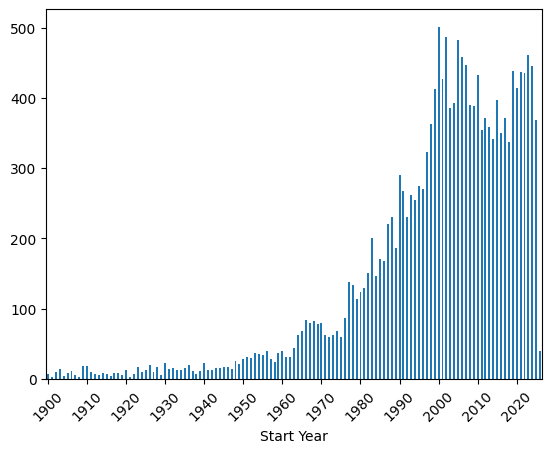

In [8]:
counts = df["Start Year"].value_counts().sort_index()

ax = counts.plot(kind="bar")

# Select ticks every 10 years
years = counts.index
tick_positions = [i for i, year in enumerate(years) if year % 10 == 0]

ax.set_xticks(tick_positions)
ax.set_xticklabels(years[tick_positions], rotation=45)
plt.show()

Text(0.5, 1.0, 'Repartition of disaster subgroups')

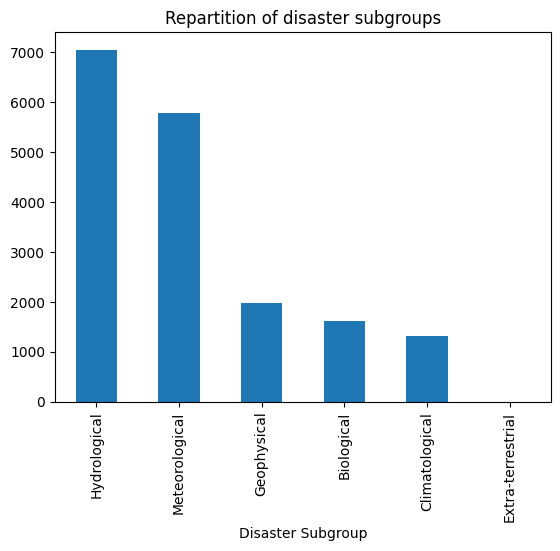

In [9]:
df["Disaster Subgroup"].value_counts().plot(kind="bar")
plt.title("Repartition of disaster subgroups")

### Extreme events exploration

In [17]:
extreme_20 = df.nlargest(20, columns="Total Deaths")[
    ["Country", "Total Deaths", "Disaster Subgroup", "Start Year"]
]

display(extreme_20)

,Country,Total Deaths,Disaster Subgroup,Start Year
17452,China,3700000.0,Hydrological,1931
17484,China,3000000.0,Climatological,1928
17612,Soviet Union,2500000.0,Biological,1917
16874,China,2000000.0,Hydrological,1959
17591,India,2000000.0,Biological,1920
17274,Bangladesh,1900000.0,Climatological,1943
16566,India,1500000.0,Climatological,1965
17290,India,1500000.0,Climatological,1942
17690,China,1500000.0,Biological,1909
17699,India,1300000.0,Biological,1907


if we focus on more recent years : 

In [24]:
extreme_10_recent = df.loc[df["Start Year"]>=1980].nlargest(10, columns="Total Deaths")[
    ["Country", "Total Deaths", "Disaster Subgroup", "Start Year","No. Injured", "No. Affected", "No. Homeless", "Total Affected", "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)"]
]

display(extreme_10_recent)

,Country,Total Deaths,Disaster Subgroup,Start Year,No. Injured,No. Affected,No. Homeless,Total Affected,Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)"
14786,Ethiopia,300000.0,Climatological,1983,NaN,7750000.0,NaN,7750000.0,NaN,NaN
6345,Haiti,222570.0,Geophysical,2010,300000.0,3400000.0,NaN,3700000.0,8000000.0,11508590.0
8564,Indonesia,165708.0,Geophysical,2004,NaN,NaN,532898.0,532898.0,4451600.0,7393017.0
14784,Sudan,150000.0,Climatological,1983,NaN,8400000.0,NaN,8400000.0,NaN,NaN
13314,Bangladesh,138866.0,Meteorological,1991,138849.0,15000000.0,300000.0,15438849.0,1780000.0,4099856.0
7045,Myanmar,138366.0,Meteorological,2008,20000.0,2400000.0,NaN,2420000.0,4000000.0,5827873.0
15123,Mozambique,100000.0,Climatological,1981,NaN,4750000.0,NaN,4750000.0,NaN,NaN
7041,China,87476.0,Geophysical,2008,366596.0,45610000.0,NaN,45976596.0,85000000.0,123842307.0
8186,Pakistan,73338.0,Geophysical,2005,128309.0,NaN,5000000.0,5128309.0,5200000.0,8352544.0
6134,Russian Federation,55736.0,Meteorological,2010,NaN,NaN,NaN,NaN,400000.0,575430.0


Text(0.5, 1.0, 'Most deathly disasters (year >1980)')

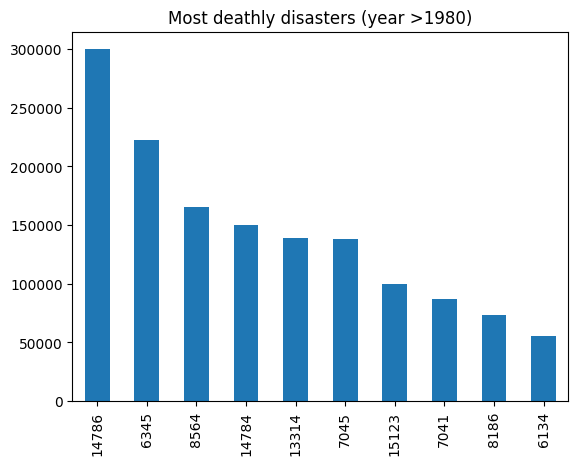

In [23]:
extreme_10_recent["Total Deaths"].plot(kind="bar")
plt.title("Most deathly disasters (year >1980)")

In [ ]:
#Statistics for extreme events versus for all events :

#Average deaths : 
print(f"The average number of deaths for extreme events is {extreme_10_recent["Total Deaths"].mean()} while the global average is {df["Total Deaths"].mean()}.")

#Average damages : 
print(f"The average amount of damages for extreme events is {extreme_10_recent["Total Damage (\'000 US$)"].mean()} while the global average is {df["Total Damage (\'000 US$)"].mean()}.")



The average number of deaths for extreme events is 143206.0 while the global average is 2566.9744854034593.
The average amount of damages for extreme events is 15547371.42857143 while the global average is 844510.1562414698.


In [27]:
extreme_economical_10_recent = df.loc[df["Start Year"]>=1980].nlargest(10, columns="Total Damage (\'000 US$)")[
    ["Country", "Total Deaths", "Disaster Subgroup", "Start Year","No. Injured", "No. Affected", "No. Homeless", "Total Affected", "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)"]
]

display(extreme_economical_10_recent)

,Country,Total Deaths,Disaster Subgroup,Start Year,No. Injured,No. Affected,No. Homeless,Total Affected,Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)"
5878,Japan,19846.0,Geophysical,2011,5933.0,362887.0,NaN,368820.0,210000000.0,292855483.0
8258,United States of America,1833.0,Meteorological,2005,NaN,500000.0,NaN,500000.0,125000000.0,200782317.0
1443,United States of America,152.0,Meteorological,2022,NaN,NaN,NaN,NaN,100000000.0,107187331.0
12341,Japan,5297.0,Geophysical,1995,34492.0,255843.0,251301.0,541636.0,100000000.0,205855147.0
3541,United States of America,88.0,Meteorological,2017,24.0,555000.0,27000.0,582024.0,95000000.0,121575099.0
7041,China,87476.0,Geophysical,2008,366596.0,45610000.0,NaN,45976596.0,85000000.0,123842307.0
3505,Puerto Rico,64.0,Meteorological,2017,NaN,540000.0,210000.0,750000.0,68000000.0,87022176.0
1899,United States of America,96.0,Meteorological,2021,NaN,14000.0,NaN,14000.0,65000000.0,75247457.0
3515,United States of America,97.0,Meteorological,2017,NaN,NaN,70000.0,70000.0,57000000.0,72945059.0
531,United States of America,219.0,Meteorological,2024,NaN,NaN,NaN,NaN,56000000.0,56000000.0


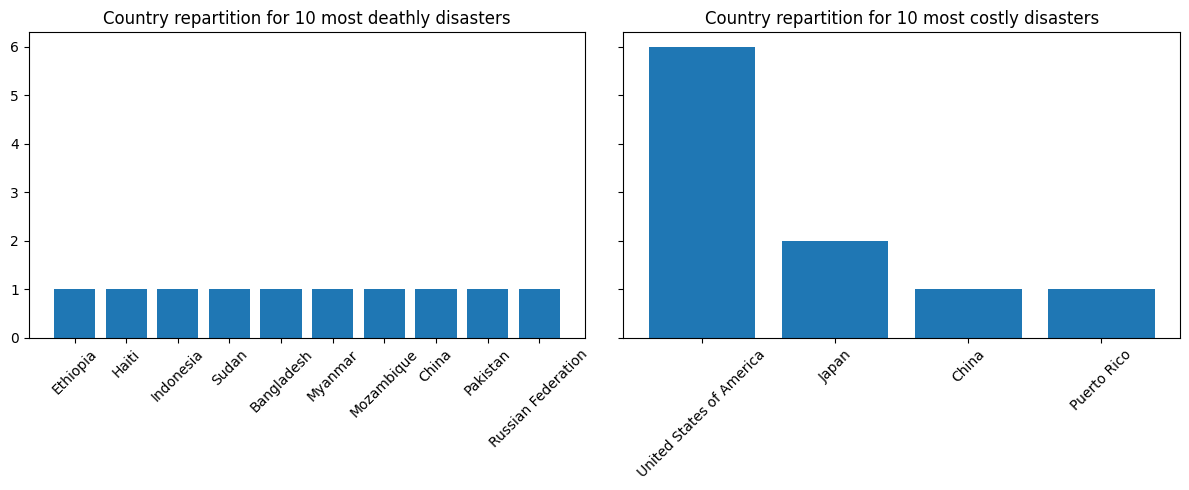

In [30]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Count occurrences
count_death = extreme_10_recent["Country"].value_counts()
count_cost = extreme_economical_10_recent["Country"].value_counts()

# Plot
ax1.bar(count_death.index, count_death.values)
ax1.set_title('Country repartition for 10 most deathly disasters')
ax1.tick_params(axis='x', rotation=45)

ax2.bar(count_cost.index, count_cost.values)
ax2.set_title("Country repartition for 10 most costly disasters")  # fixed typo
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()